# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [104]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

base.head(10)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [105]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [106]:
base['weight'] = pd.to_numeric(base['weight'], errors='coerce') # Mudando o tipo da coluna weight de object para float

In [107]:
print(base.describe()) # Aqui podemos perceber outliers nas colunas height e weight

                age        gender        height       weight   cholesterol  \
count  10000.000000  10000.000000  10000.000000  9976.000000  10000.000000   
mean      53.288300      1.345400    164.308200    74.300521      1.365000   
std        6.796234      0.475522      8.178796    14.572144      0.677658   
min       30.000000      1.000000     70.000000    30.000000      1.000000   
25%       48.000000      1.000000    159.000000    65.000000      1.000000   
50%       54.000000      1.000000    165.000000    72.000000      1.000000   
75%       58.000000      2.000000    170.000000    82.000000      2.000000   
max       65.000000      2.000000    250.000000   200.000000      3.000000   

               gluc         smoke          alco        active  cardio_disease  
count  10000.000000  10000.000000  10000.000000  10000.000000    10000.000000  
mean       1.222200      0.089000      0.053700      0.797200        0.503100  
std        0.565561      0.284758      0.225436      0.40

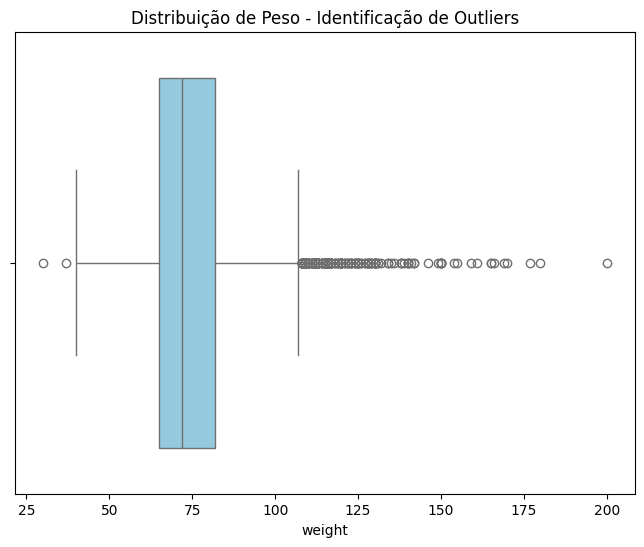

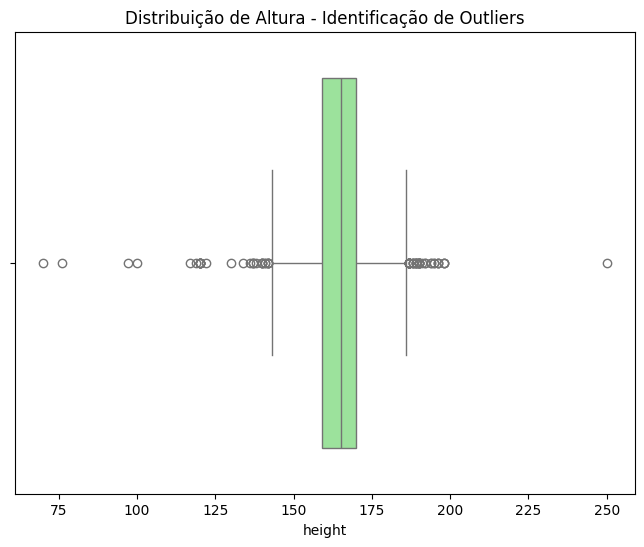

In [108]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=base['weight'], color='skyblue')
plt.title('Distribuição de Peso - Identificação de Outliers')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=base['height'], color='lightgreen')
plt.title('Distribuição de Altura - Identificação de Outliers')
plt.show()

In [109]:
base[(base['height'] > 100) & (base['weight'] > 30)] # Alterando dados sem sentido

Q1 = base['weight'].quantile(0.25) 
Q3 = base['weight'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


base_limpo = base[(base['weight'] >= limite_inferior) & (base['weight'] <= limite_superior)]

print(f"Dados originais: {len(base)}")
print(f"Dados após remover outliers: {len(base_limpo)}")

Dados originais: 10000
Dados após remover outliers: 9729


In [110]:
dados_faltantes= (base.isnull().sum() / len(base)) * 100
print(dados_faltantes)   

# 0.24 de dados faltantes na coluna weight. Sendo uma quantidade pequena, optei por excluir.

age               0.00
gender            0.00
height            0.00
weight            0.24
cholesterol       0.00
gluc              0.00
smoke             0.00
alco              0.00
active            0.00
cardio_disease    0.00
dtype: float64


In [111]:
base.dropna(subset=['weight'], inplace=True)

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


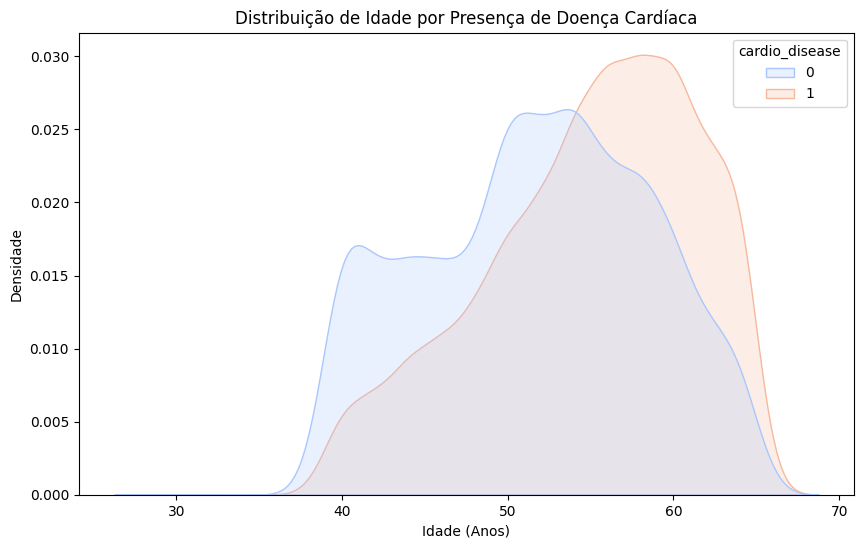

In [112]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=base_limpo, x='age', hue='cardio_disease', fill=True, palette='coolwarm')
plt.title('Distribuição de Idade por Presença de Doença Cardíaca')
plt.xlabel('Idade (Anos)')
plt.ylabel('Densidade')
plt.show()

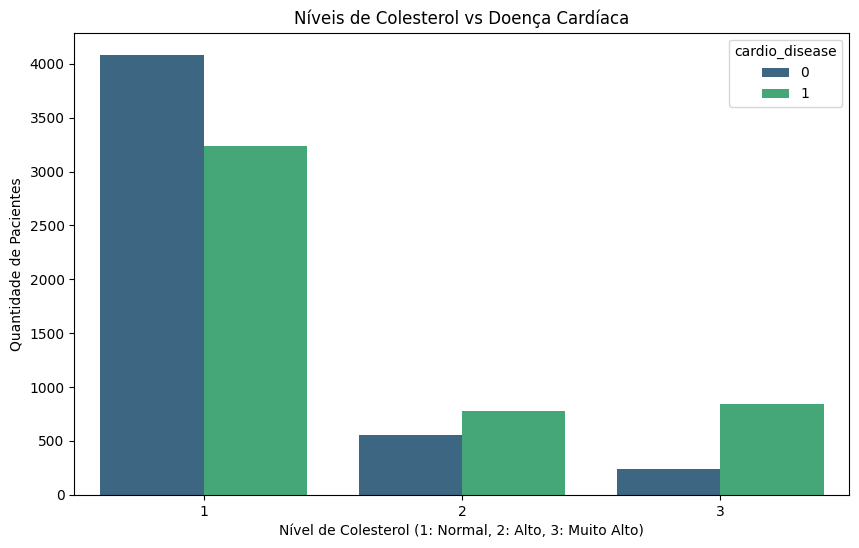

In [113]:
plt.figure(figsize=(10, 6))
sns.countplot(data=base_limpo, x='cholesterol', hue='cardio_disease', palette='viridis')
plt.title('Níveis de Colesterol vs Doença Cardíaca')
plt.xlabel('Nível de Colesterol (1: Normal, 2: Alto, 3: Muito Alto)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

   height  weight        bmi
0     168    62.0  21.967120
1     156    85.0  34.927679
2     165    64.0  23.507805
3     169    82.0  28.710479
4     156    56.0  23.011177


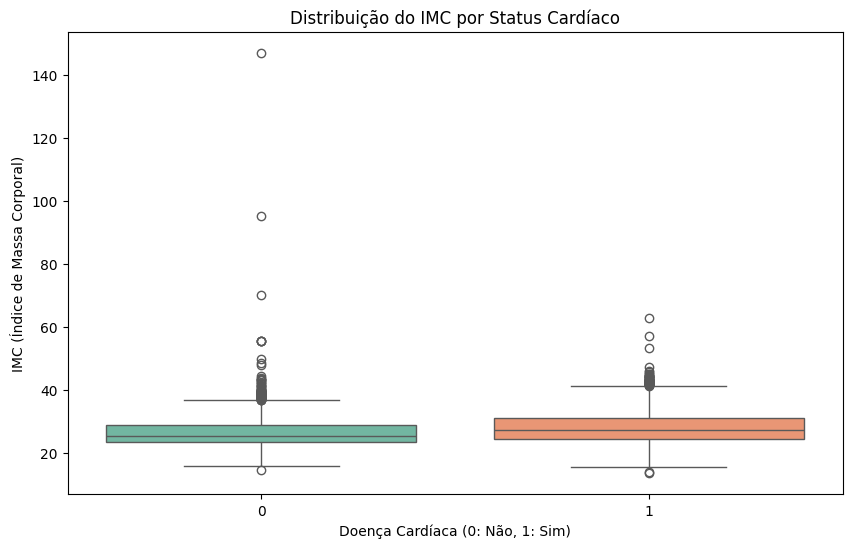

In [114]:
base_limpo = base_limpo.copy()

base_limpo['bmi'] = base_limpo['weight'] / ((base_limpo['height'] / 100) ** 2)

print(base_limpo[['height', 'weight', 'bmi']].head())

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=base_limpo, 
    x='cardio_disease', 
    y='bmi', 
    hue='cardio_disease', 
    palette='Set2', 
    legend=False           
)

plt.title('Distribuição do IMC por Status Cardíaco')
plt.xlabel('Doença Cardíaca (0: Não, 1: Sim)')
plt.ylabel('IMC (Índice de Massa Corporal)')
plt.show()

In [115]:
# O perfil de maior risco identificado na base de dados é composto por indivíduos acima de 55 anos, com níveis de colesterol acima do normal e IMC elevado. Estratégias de prevenção focadas no controle de peso e na dieta (colesterol) seriam, teoricamente, as mais eficazes para reduzir a incidência nesta população.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



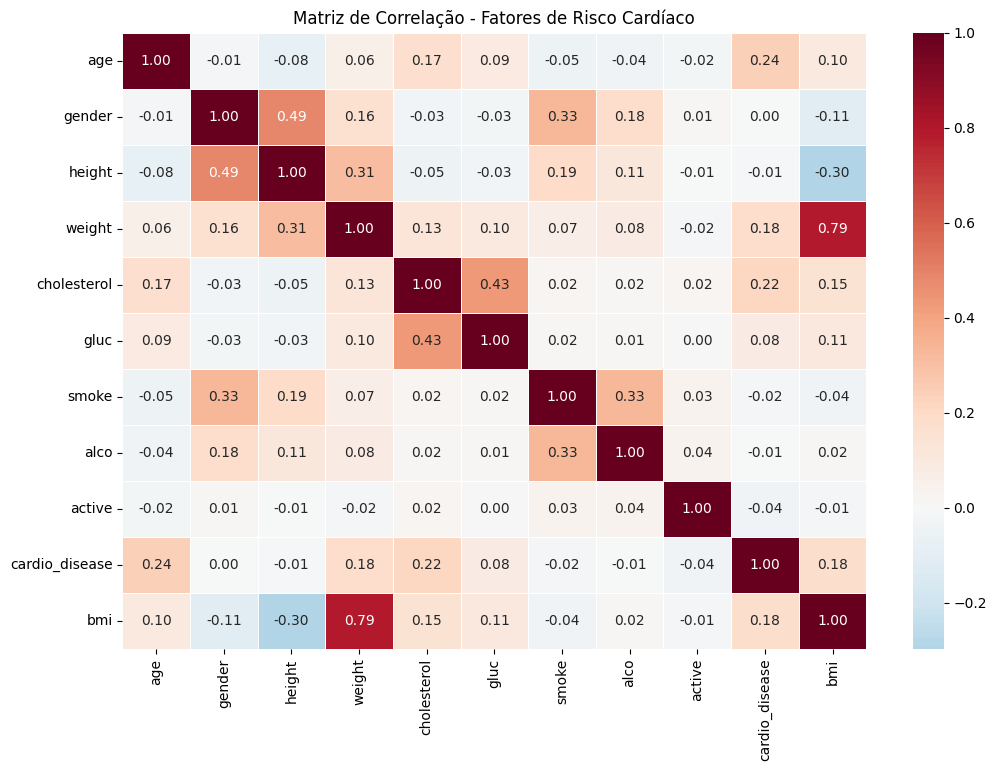

In [116]:
corr = base_limpo.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)

plt.title('Matriz de Correlação - Fatores de Risco Cardíaco')
plt.show()

A matriz de correlação revelou que o Colesterol e a Glicose caminham juntos. Pacientes com níveis elevados de um costumam apresentar o outro alterado. Além disso, o IMC (BMI) mostrou-se um correlacionador mais fiel à doença do que o peso isolado, provando que a composição corporal é o que realmente impacta o coração.
A partir dos 50 anos, a probabilidade de diagnóstico aumenta independentemente de outras variáveis.
Embora a correlação direta seja menor na matriz, os dados sugerem que pacientes "Ativos" conseguem manter níveis de colesterol mais controlados, agindo como um fator de proteção indireto.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [117]:
X = base_limpo.drop(columns=['cardio_disease'])
y = base_limpo['cardio_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 7783 amostras
Teste: 1946 amostras


In [118]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

In [119]:
print("Distribuição das classes no treino:")
print(y_train.value_counts(normalize=True))

Distribuição das classes no treino:
cardio_disease
0    0.501606
1    0.498394
Name: proportion, dtype: float64


In [120]:
print("\n--- X_train Padronizado (Primeiras linhas) ---")
print(X_train.head())

print("\n--- Verificação de Nulos ---")
print(X_train.isnull().sum().sum())


--- X_train Padronizado (Primeiras linhas) ---
        age    gender    height    weight  cholesterol      gluc     smoke  \
0 -0.192715 -0.723457 -1.030207 -0.567814     2.448786 -0.385196 -0.312639   
1 -1.223172 -0.723457  0.219186 -0.328494    -0.531263 -0.385196 -0.312639   
2  0.984950 -0.723457 -0.530450 -1.365551    -0.531263 -0.385196 -0.312639   
3 -0.781548  1.382252  0.344125  0.389469    -0.531263 -0.385196 -0.312639   
4 -1.370380 -0.723457  0.718943  0.070375    -0.531263 -0.385196 -0.312639   

       alco    active       bmi  
0 -0.238835  0.503090 -0.010049  
1 -0.238835  0.503090 -0.441493  
2 -0.238835 -1.987717 -1.097850  
3 -0.238835  0.503090  0.165751  
4 -0.238835  0.503090 -0.324192  

--- Verificação de Nulos ---
0


# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [121]:
# seu código aqui

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [122]:
modelo_cardio = LogisticRegression()
modelo_cardio.fit(X_train, y_train)

y_pred = modelo_cardio.predict(X_test)

In [123]:
print(f"Intercept (Viés): {modelo_cardio.intercept_[0]:.4f}")

coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_cardio.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("\n--- Pesos das Variáveis (Importância) ---")
print(coef_df)

Intercept (Viés): 0.0046

--- Pesos das Variáveis (Importância) ---
      Variável  Coeficiente
3       weight     0.505666
0          age     0.458328
4  cholesterol     0.413550
1       gender     0.030686
7         alco    -0.019506
6        smoke    -0.048001
8       active    -0.072406
5         gluc    -0.077414
9          bmi    -0.146447
2       height    -0.174422



--- Relatório de Performance ---
              precision    recall  f1-score   support

           0       0.61      0.64      0.63       976
           1       0.62      0.59      0.61       970

    accuracy                           0.62      1946
   macro avg       0.62      0.62      0.62      1946
weighted avg       0.62      0.62      0.62      1946

Acurácia Global: 61.66%


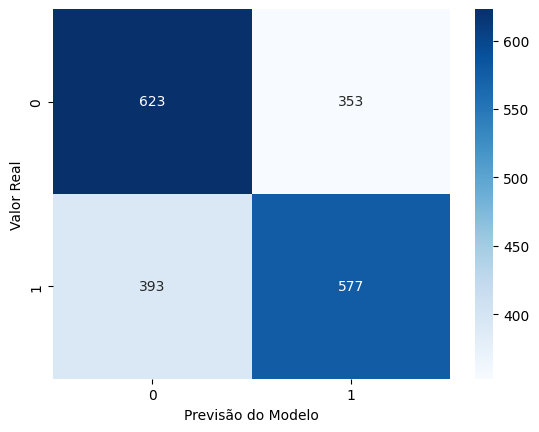

In [124]:
print("\n--- Relatório de Performance ---")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Global: {acc:.2%}")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

In [ ]:
# Doenças cardíacas dependem de muitos fatores que podem não estar na tabela (genética, estresse, sono).
# Além disso excluir alguns dados pode ter removido informações importantes, porém sendo um caso delicado, optei por não fazer a imputação.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A regressão logística é um modelo estatístico que utiliza a estrutura matemática da regressão linear (como a combinação de pesos e variáveis) para estimar a probabilidade de um evento ocorrer, mas diferencia-se por aplicar a função sigmoide para "esmagar" os resultados entre 0 e 1. Essa característica a define como um modelo de classificação, pois permite converter valores contínuos em categorias discretas (como "doente" ou "saudável") com base em um ponto de corte, sendo ideal para problemas onde o objetivo final é decidir entre grupos em vez de prever um número exato.